In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as st
import pandas as pd

In [2]:
noise_rates = [0,4,8]
result_path = '/g100_scratch/userexternal/csartor1/results/Paper/'
with open("/g100_work/EIRI_E_POLIMI/no_paper/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"
num_sim = 25

Noise level: 0
baselines : 2.9643799464905646e-22
baseline vs cr : 1.7489069310011957e-16
baselines vs cr wNO : 1.3010685317571493e-05
cr : 2.9643799464905646e-22
Noise level: 4
baselines : 3.036841823559529e-22
baseline vs cr : 2.619980894380765e-17
baselines vs cr wNO : 4.0782369211625605e-17
cr : 2.9643799464905646e-22
Noise level: 8
baselines : 3.595565657535253e-22
baseline vs cr : 8.847293939046872e-18
baselines vs cr wNO : 8.847293939046872e-18
cr : 3.4262933658624887e-22


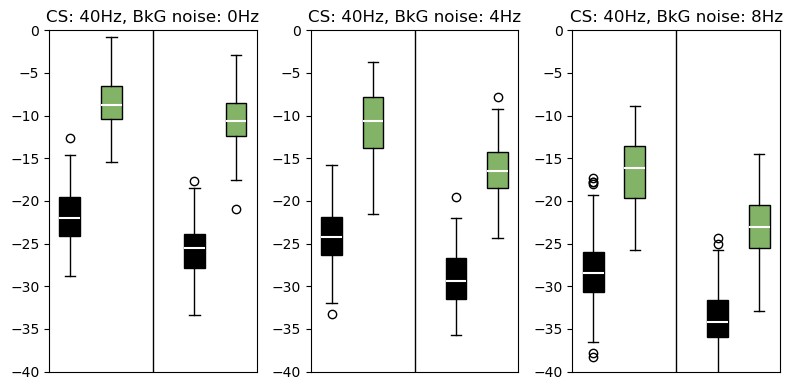

In [16]:
fig, axs = plt.subplots(1,3,figsize=(8,4))
colors = [without_NO_color, with_NO_color, without_NO_color, with_NO_color]
medianprops = dict(linewidth=1.5, color='white')
positions = [1,2,4,5]
folder_path = result_path + f"without_NO/"
folder_path_NO = result_path + f"with_NO/"
for i,noise in enumerate([0,4,8]):
    sdf_change_bs = []
    sdf_change_cr = []
    sdf_change_bs_NO = []
    sdf_change_cr_NO = []
    for k in range (0,num_sim):
        
        file_path = folder_path+ f"simulation_{noise}Hz_sim{k}/"
        file_path_NO = folder_path_NO+ f"simulation_{noise}Hz_sim{k}/"
        
        df_sdf_change = pd.read_csv(os.path.join(file_path,'sdf_grid.csv'))
        sdf_baseline = df_sdf_change.iloc[:,0].values
        sdf_cr = df_sdf_change.iloc[:,1].values
        
        df_sdf_change_NO = pd.read_csv(os.path.join(file_path_NO,'sdf_grid.csv'))
        sdf_baseline_NO = df_sdf_change_NO.iloc[:,0].values
        sdf_cr_NO = df_sdf_change_NO.iloc[:,1].values
        
        sim_bs = sdf_baseline[1:] - sdf_baseline[1] #np.median(sdf_baseline[1:3])
        sim_cr = sdf_cr[1:] - sdf_cr[1]#np.median(sdf_cr[1:3])
        sim_bs_NO = sdf_baseline_NO[1:] - sdf_baseline_NO[1] #np.median(sdf_baseline[1:3])
        sim_cr_NO = sdf_cr_NO[1:] - sdf_cr_NO[1]#np.median(sdf_cr[1:3])
    
        sdf_change_bs.append(sim_bs[-5:])
        sdf_change_cr.append(sim_cr[-5:])
        
        sdf_change_bs_NO.append(sim_bs_NO[-5:])
        sdf_change_cr_NO.append(sim_cr_NO[-5:])
        
    sdf_change_bs = np.array(sdf_change_bs).flatten()
    sdf_change_cr = np.array(sdf_change_cr).flatten()
    
    sdf_change_bs_NO = np.array(sdf_change_bs_NO).flatten()
    sdf_change_cr_NO = np.array(sdf_change_cr_NO).flatten()
    

    boxes = [sdf_change_bs,sdf_change_bs_NO,sdf_change_cr,sdf_change_cr_NO]
    print(f"Noise level: {noise}")
    stat, p= st.wilcoxon(x=sdf_change_bs,y=sdf_change_bs_NO)
    print(f"baselines : {p}")
    stat, p = st.wilcoxon(x=sdf_change_bs,y=sdf_change_cr)
    print(f"baseline vs cr : {p}")
    stat, p = st.wilcoxon(x=sdf_change_bs_NO,y=sdf_change_cr_NO)
    print(f"baselines vs cr wNO : {p}")
    stat, p = st.wilcoxon(x=sdf_change_cr,y=sdf_change_cr_NO)
    print(f"cr : {p}")
    bp1 = axs[i].boxplot(boxes, patch_artist=True, medianprops=medianprops, positions=positions)

    for patch, color  in zip(bp1['boxes'],colors):
        patch.set_facecolor(color)
    axs[i].axvline(3,linewidth=1, color='black')
    axs[i].set_xticks([])
    axs[i].set_ylim(-40,0)
    axs[i].set_title(f'CS: 40Hz, BkG noise: {noise}Hz')  

plt.tight_layout()
plt.show()

Noise level: 0
baselines : 0.17295855283737183
Noise level: 4
baselines : 0.978915274143219
Noise level: 8
baselines : 0.615043044090271


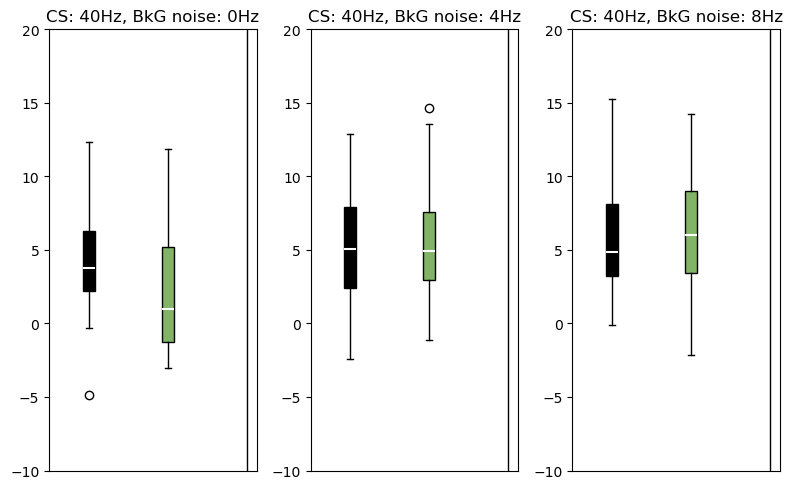

In [27]:
fig, axs = plt.subplots(1,3,figsize=(8,5))
colors = [without_NO_color, with_NO_color, without_NO_color, with_NO_color]
medianprops = dict(linewidth=1.5, color='white')
positions = [1,2]
folder_path = result_path + f"without_NO/"
folder_path_NO = result_path + f"with_NO/"
for i,noise in enumerate([0,4,8]):
    sdf_change_median = []
    sdf_change_median_NO = []

    for k in range (0,num_sim):
        
        file_path = folder_path+ f"simulation_{noise}Hz_sim{k}/"
        file_path_NO = folder_path_NO+ f"simulation_{noise}Hz_sim{k}/"
        
        df_sdf_change = pd.read_csv(os.path.join(file_path,'sdf_grid.csv'))
        sdf_baseline = df_sdf_change.iloc[:,0].values
        sdf_cr = df_sdf_change.iloc[:,1].values
        
        df_sdf_change_NO = pd.read_csv(os.path.join(file_path_NO,'sdf_grid.csv'))
        sdf_baseline_NO = df_sdf_change_NO.iloc[:,0].values
        sdf_cr_NO = df_sdf_change_NO.iloc[:,1].values
        
        sim_bs = sdf_baseline[1:] - sdf_baseline[1] #np.median(sdf_baseline[1:3])
        sim_cr = sdf_cr[1:] - sdf_cr[1]#np.median(sdf_cr[1:3])
        sim_bs_NO = sdf_baseline_NO[1:] - sdf_baseline_NO[1] #np.median(sdf_baseline[1:3])
        sim_cr_NO = sdf_cr_NO[1:] - sdf_cr_NO[1]#np.median(sdf_cr[1:3])

        median_bs_cr = np.median(sim_bs[-5:] - sim_cr[-5:])
        median_bs_cr_NO = np.median(sim_bs_NO[-5:] - sim_cr_NO[-5:])
        
        sdf_change_median.append(median_bs_cr)        
        sdf_change_median_NO.append(median_bs_cr_NO)

        
    sdf_change_median = np.array(sdf_change_median).flatten()
    sdf_change_median_NO = np.array(sdf_change_median_NO).flatten()    

    boxes = [sdf_change_median,sdf_change_median_NO]
    print(f"Noise level: {noise}")
    stat, p= st.wilcoxon(x=sdf_change_median,y=sdf_change_median_NO)
    print(f"baselines : {p}")
    bp1 = axs[i].boxplot(boxes, patch_artist=True, medianprops=medianprops, positions=positions)

    for patch, color  in zip(bp1['boxes'],colors):
        patch.set_facecolor(color)
    axs[i].axvline(3,linewidth=1, color='black')
    axs[i].set_xticks([])
    axs[i].set_ylim(-10,20)
    axs[i].set_title(f'CS: 40Hz, BkG noise: {noise}Hz')  

plt.tight_layout()
plt.show()